In [23]:
import pandas as pd 
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df


,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [2]:
import numpy as np
df["Weather"]=np.where(df['Weather']=='Cloudy',0,np.where(df['Weather']=="Rain",1,2))


In [3]:
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,Hot,High,Weak,No
1,Day 2,2,Hot,High,Strong,No
2,Day 3,0,Hot,High,Weak,Yes
3,Day 4,1,Mild,High,Weak,Yes
4,Day 5,1,Cool,Normal,Weak,Yes
5,Day 6,1,Cool,Normal,Strong,No
6,Day 7,0,Cool,Normal,Strong,Yes
7,Day 8,2,Mild,High,Weak,No
8,Day 9,2,Cool,Normal,Weak,Yes
9,Day 10,1,Mild,Normal,Weak,Yes


In [4]:
df['Temperature']=np.where(df["Temperature"]=="Cool",0,np.where(df['Temperature']=='Hot',1,2))

In [7]:
df['Humidity']=np.where(df['Humidity']=='High',0,1)

In [9]:
df['Wind']=np.where(df['Wind']=='Strong',0,1)

In [ ]:
df['Wind']=np.where(df['Wind']=='Strong',0,1)

In [11]:
df['Play_Sports?']=np.where(df['Play_Sports?']=='No',0,1

In [13]:
df=df.drop(columns="Day")

In [14]:
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [15]:
df.columns

Index(['Weather', 'Temperature', 'Humidity', 'Wind', 'Play_Sports?'], dtype='object')

In [16]:
x=df[['Weather', 'Temperature', 'Humidity', 'Wind']]
y=df["Play_Sports?"]
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [17]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(criterion="entropy")
model = dtree.fit(x,y)
prediction = model.predict(x)
print(prediction)


[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [18]:
diff=pd.DataFrame({'Actual':y,'Predicted':prediction})
diff

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [19]:
from sklearn.tree import export_text
text_representation = export_text(dtree)
print(text_representation)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



In [20]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm = confusion_matrix(y,prediction)
print(cm)

[[5 0]
 [0 9]]


In [21]:
accuracy_score(y,prediction)


1.0

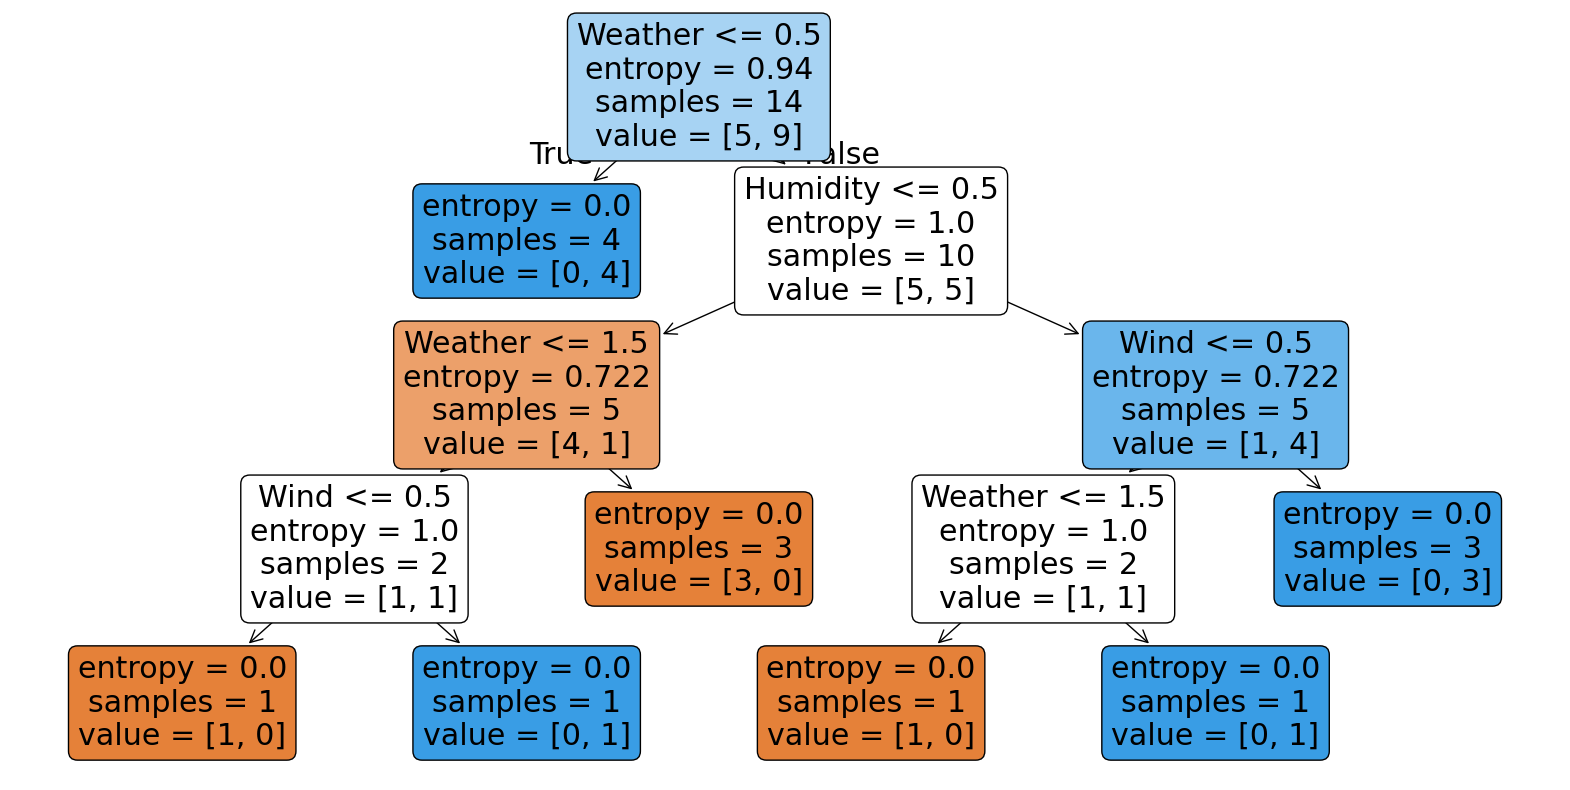

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()


In [24]:
import pandas as pd 
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df


,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [25]:
df.columns


Index(['CGPA', 'Communication', 'Apptitude', 'Programming Skill',
       'Job Offered'],
      dtype='object')

In [26]:
x=df[['CGPA', 'Communication', 'Apptitude', 'Programming Skill']]
y=df['Job Offered']
print(x.shape)
print(y.shape)

(18, 4)
(18,)


In [27]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(criterion="entropy")
model = dtree.fit(x,y)
prediction = model.predict(x)
print(prediction)


[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [28]:
diff=pd.DataFrame({'Actual':y,'Predicted':prediction})
diff

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [29]:
from sklearn.tree import export_text
text_representation = export_text(dtree)
print(text_representation)

|--- feature_2 <= 0.50
|   |--- class: 0
|--- feature_2 >  0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- class: 0
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 1



In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm = confusion_matrix(y,prediction)
print(cm)

[[10  0]
 [ 0  8]]


In [31]:
accuracy_score(y,prediction)


1.0

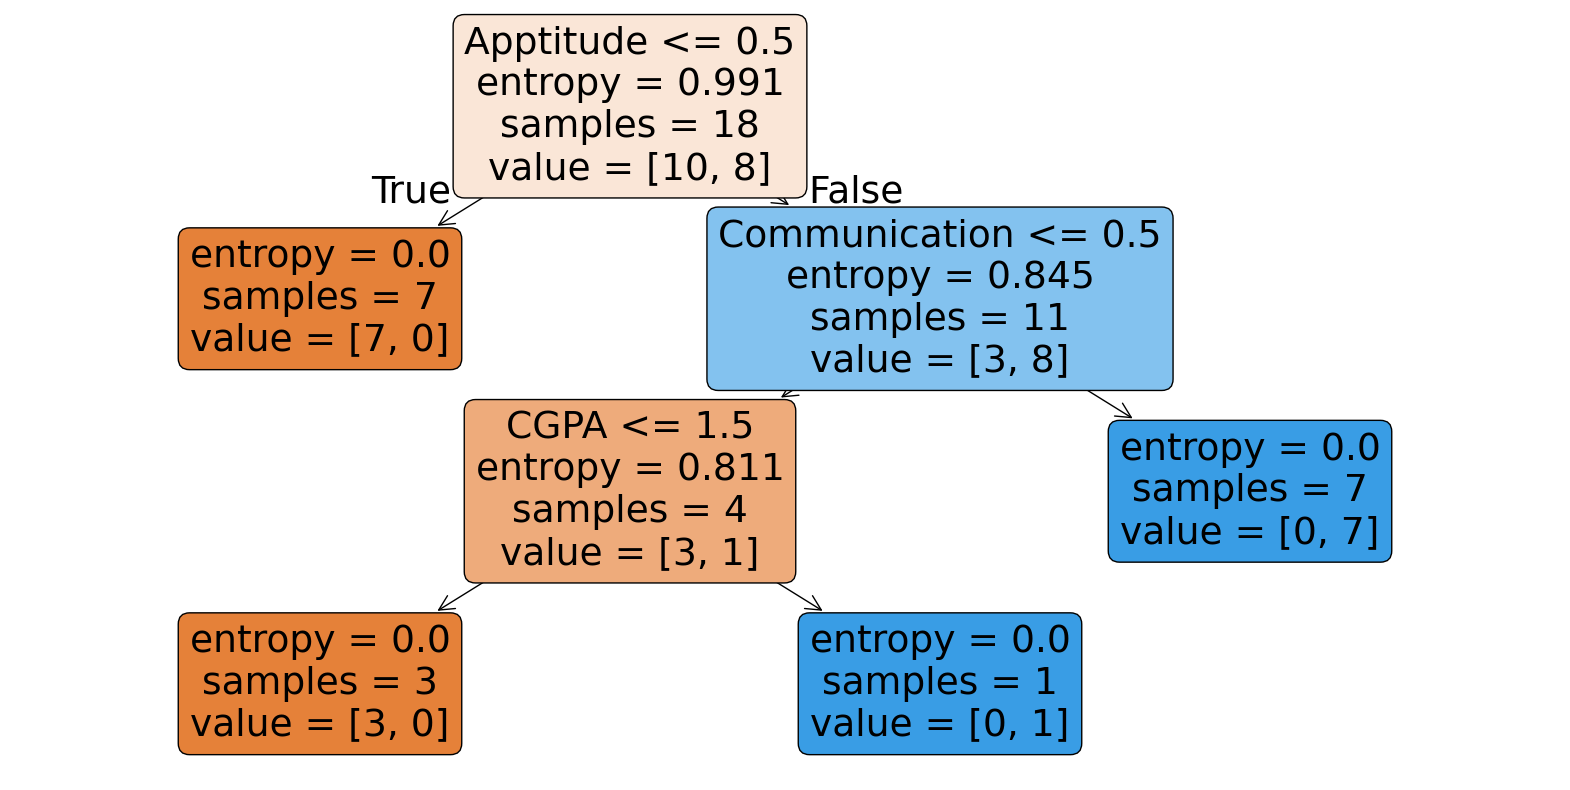

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()


In [33]:
dtree.get_depth()

3

In [35]:
import pandas as pd 
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [36]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [37]:
x=[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=[['Outcome']]

In [48]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [56]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(criterion="entropy",random_state=1)
model = dtree.fit(x_train,y_train)
prediction = model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 1 0
 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0
 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0
 0 1 0 1 0 1]


In [57]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm = confusion_matrix(y_test,prediction)
print(cm)

[[78 21]
 [21 34]]


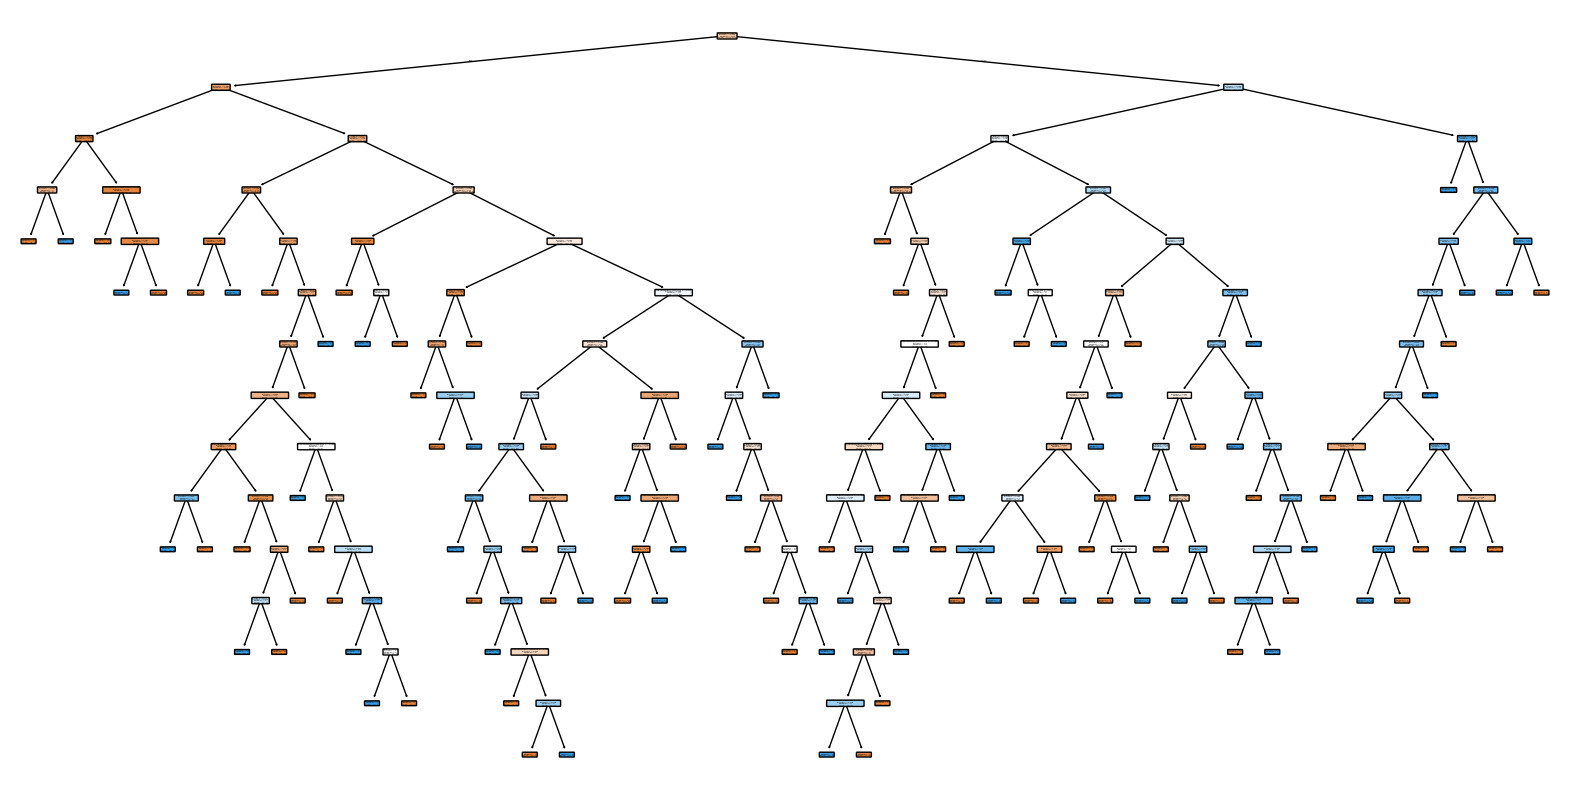

In [58]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()


In [75]:
import pandas as pd 
df=pd.read_csv("titanic.csv")
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [76]:
import pandas as pd
df['Age']=df['Age'].fillna(df['Age'].median())

In [77]:
df['Sex']=np.where(df['Sex']=="male",1,0)

In [78]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [86]:
x=df[['Pclass',  'Sex', 'Age', 'SibSp','Parch', 'Fare']]
y=df['Survived']
print(x.shape)
print(y.shape)    

(891, 6)
(891,)


In [ ]:
x.colum

In [80]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [81]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [84]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(criterion='entropy',n_estimators=100,random_state=42)
rf_classifier= rf_classifier.fit(x_train,y_train)
prediction = rf_classifier.predict(x_test)
print(prediction)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [85]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm = confusion_matrix(y_test,prediction)
print(cm)

[[95 11]
 [29 44]]
